# I) Nettoyage des données de transactions

La première étape consiste à traiter les valeurs manquantes, puis à supprimer les transactions annulées ainsi que celles dont le prix ou la quantité est nul.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config

set_config(transform_output="pandas")

df = pd.read_excel("Online Retail.xlsx")
# Typage
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
print(df.head(20))
print(f"\nTaille : {df.shape}")

   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5     536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6     536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7     536366     22633               HAND WARMER UNION JACK         6   
8     536366     22632            HAND WARMER RED POLKA DOT         6   
9     536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   
10    536367     22745           POPPY'S PLAYHOUSE BEDROOM          6   
11    536367     22748            POPPY'S PLAYHOUSE KITCHEN         6   
12    536367     22749    FELTCRAFT PRINCESS CHARLO

In [2]:
df = df.query("'C' not in `InvoiceNo` and `Quantity` > 0 and `UnitPrice` > 0")
print(f"\nTaille : {df.shape}")


Taille : (530104, 8)


In [3]:
df["CustomerID"].isna().value_counts()

CustomerID
False    397884
True     132220
Name: count, dtype: int64

In [4]:
df.dropna(subset="CustomerID", inplace=True)
print(f"\nTaille : {df.shape}")


Taille : (397884, 8)


In [5]:
df.isna().value_counts()

InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  CustomerID  Country
False      False      False        False     False        False      False       False      397884
Name: count, dtype: int64

In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


À partir de ce jeu de données, un nouveau jeu de données sera créé dans lequel chaque ligne représentera un client, et non plus une transaction. Des variables seront ensuite construites afin de segmenter les clients de manière générale. Parmi celles-ci, le nombre total de transactions par client permettra d’évaluer la fréquence des transactions, le montant total dépensé par client permettra d’identifier les clients qui dépensent le plus, et la récence permettra de déterminer si un client a effectué une transaction récemment.

In [7]:
nb_transaction = df.groupby("CustomerID")["InvoiceNo"].nunique()

data = pd.DataFrame({"nb_transaction": nb_transaction})

data["nb_transaction"].describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: nb_transaction, dtype: float64

Le nombre moyen de transactions par client est de 4,27, avec un écart-type de 7,70. Le nombre de transactions varie de 1 à 209 par client, tandis que la médiane s’établit à 2 transactions. Analysons maintenant la distribution de cette variable.

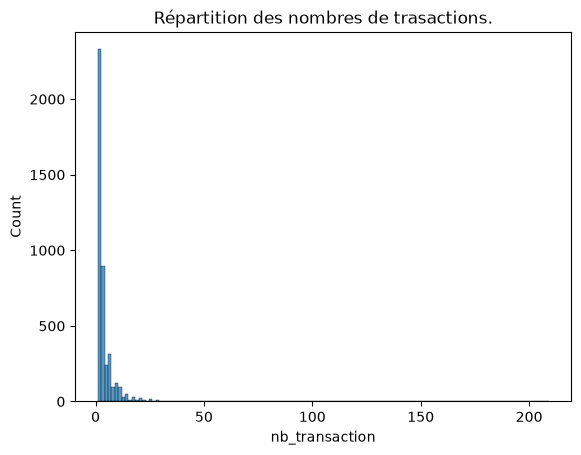

In [8]:
import seaborn as sns

sns.histplot(data, x="nb_transaction")
plt.title("Répartition des nombres de trasactions.")
plt.show()

La distribution étant asymétrique, une transformation logarithmique sera appliquée afin de la rendre plus équilibrée.

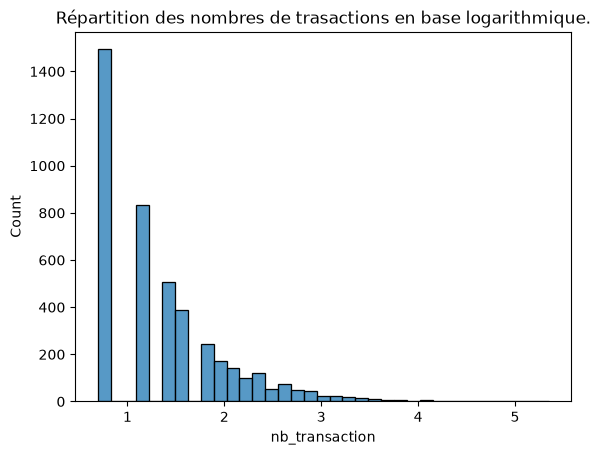

In [27]:
import numpy as np

sns.histplot(data, x=np.log1p(data["nb_transaction"]))
plt.title("Répartition des nombres de trasactions en base logarithmique.")
plt.show()

On observe que la distribution est désormais davantage centrée. Le nombre de clients diminue progressivement à mesure que le nombre de transactions augmente.

In [10]:
df["montant"] = df["Quantity"] * df["UnitPrice"]
data["montant_total"] = df.groupby("CustomerID")["montant"].sum()
data

,nb_transaction,montant_total
CustomerID,,
12346.0,1,77183.60
12347.0,7,4310.00
12348.0,4,1797.24
12349.0,1,1757.55
12350.0,1,334.40
...,...,...
18280.0,1,180.60
18281.0,1,80.82
18282.0,2,178.05


In [11]:
data["montant_total"].describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: montant_total, dtype: float64

Les clients de ce jeu de données dépensent en moyenne 2 054 euros.

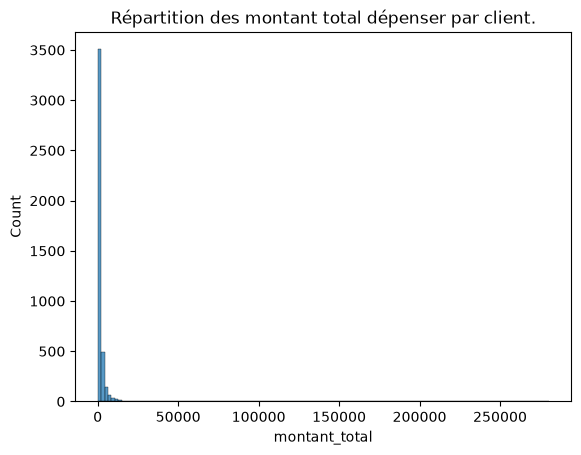

In [12]:
sns.histplot(data, x="montant_total")
plt.title("Répartition des montant total dépenser par client.")
plt.show()

On observe que le nombre de clients diminue à mesure que le montant total dépensé augmente. La distribution étant fortement asymétrique, une transformation logarithmique sera appliquée.

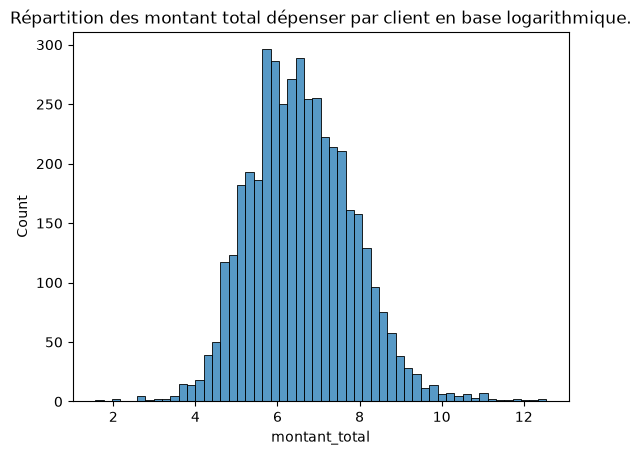

In [13]:
sns.histplot(data, x=np.log1p(data["montant_total"]))
plt.title("Répartition des montant total dépenser par client en base logarithmique.")
plt.show()

Après la transformation logarithmique, la distribution obtenue présente une forme normale et correctement centrée. Observons maintenant la première surface obtenue.


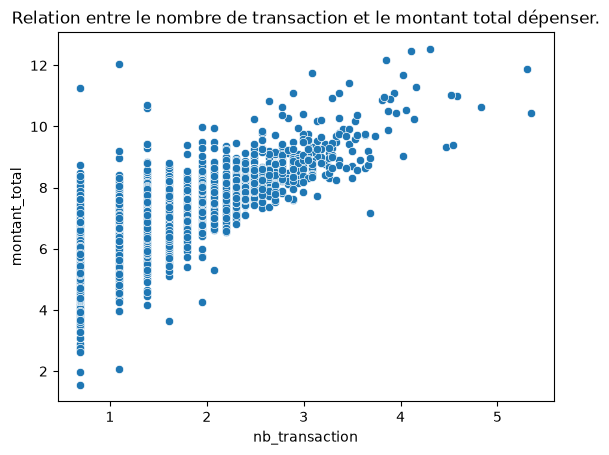

In [15]:
sns.scatterplot(x=np.log1p(data["nb_transaction"]), y=np.log1p(data["montant_total"]))
plt.title("Relation entre le nombre de transaction et le montant total dépenser.")
plt.show()

On observe une relation entre les deux variables : plus le nombre de transactions augmente, plus le montant dépensé est élevé. Pour les faibles nombres de transactions, les valeurs présentent d’abord un caractère discret, puis les écarts entre elles diminuent progressivement jusqu’à former une partie continue. Observons maintenant les variables temporelles.

In [ ]:
from datetime import timedelta

data["recence"] = (
    df["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].max()
    + timedelta(days=1)
).dt.days
data

,nb_transaction,montant_total,recence
CustomerID,,,
12346.0,1,77183.60,326
12347.0,7,4310.00,2
12348.0,4,1797.24,75
12349.0,1,1757.55,19
12350.0,1,334.40,310
...,...,...,...
18280.0,1,180.60,278
18281.0,1,80.82,181
18282.0,2,178.05,8


In [19]:
data["recence"].describe()

count    4338.000000
mean       92.536422
std       100.014169
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: recence, dtype: float64

La récence moyenne des clients de ce jeu de données est de 92 jours, soit environ trois mois, ce qui indique que les dernières transactions ne sont globalement pas très récentes.

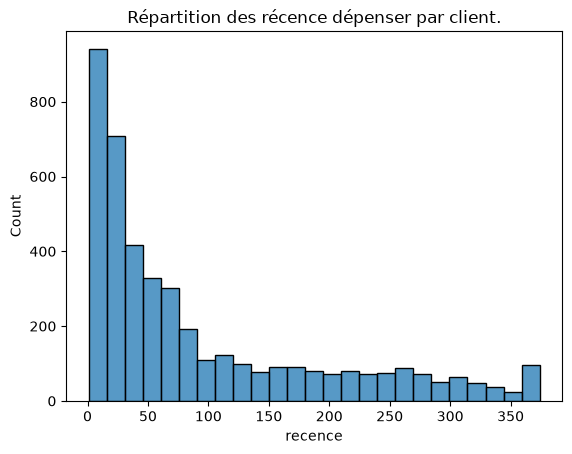

In [25]:
sns.histplot(data, x="recence")
plt.title("Répartition des récence dépenser par client.")
plt.show()

On observe que la majorité des clients présentent une récence faible. Le nombre de clients diminue ensuite fortement avant de se stabiliser autour d’un plateau. Afin de mieux centrer la distribution, une transformation logarithmique sera appliquée.

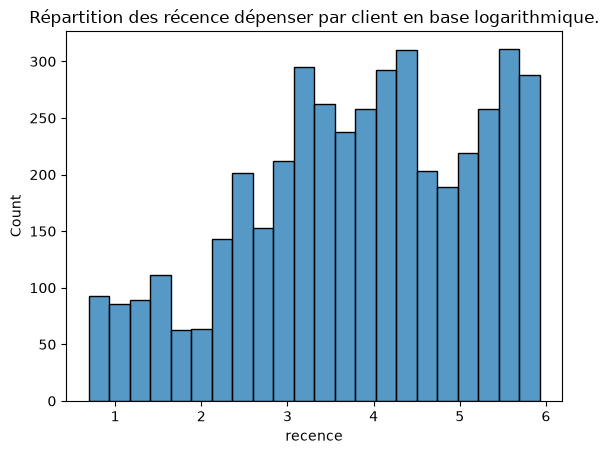

In [29]:
sns.histplot(data, x=np.log1p(data["recence"]))
plt.title("Répartition des récence dépenser par client en base logarithmique.")
plt.show()

La distribution obtenue ne semble correspondre à aucune loi usuelle. Observons maintenant, sur une surface 3D, les trois variables qui constituent déjà une base pour un algorithme de segmentation client.

In [28]:
import plotly.express as px
import numpy as np

fig = px.scatter_3d(
    data,
    x=np.log1p(data["montant_total"]),
    y=np.log1p(data["nb_transaction"]),
    z=np.log1p(data["recence"]),
)

fig.update_traces(marker_size=3)

fig.show()

On observe qu’il semble possible d’identifier des clusters, bien que leur séparation ne soit pas clairement définie. Nous allons donc tester les algorithmes K-means et Spectral Clustering.


In [30]:
data["montant_total"] = np.log1p(data["montant_total"])
data["nb_transaction"] = np.log1p(data["nb_transaction"])
data["recence"] = np.log1p(data["recence"])

data.describe()

,nb_transaction,montant_total,recence
count,4338.000000,4338.000000,4338.000000
mean,1.345582,6.593627,3.830734
std,0.683104,1.257578,1.340261
min,0.693147,1.558145,0.693147
25%,0.693147,5.731446,2.944439
50%,1.098612,6.515431,3.951244
75%,1.791759,7.416222,4.962845
max,5.347108,12.543284,5.926926


In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(StandardScaler())

data_prep = pipeline.fit_transform(data)
data_prep

,nb_transaction,montant_total,recence
CustomerID,,,
12346.0,-0.955214,3.706225,1.461993
12347.0,1.074425,1.411843,-2.038734
12348.0,0.386304,0.716489,0.373104
12349.0,-0.955214,0.698739,-0.623086
12350.0,-0.955214,-0.618962,1.424558
...,...,...,...
18280.0,-0.955214,-1.106875,1.343533
18281.0,-0.955214,-1.740933,1.024749
18282.0,-0.361583,-1.118121,-1.218940


In [79]:
from sklearn.cluster import KMeans, SpectralClustering

cluster = KMeans(n_clusters=3, random_state=42, n_init="auto").fit_predict(data_prep)
cluster

array([0, 1, 0, ..., 0, 1, 0], shape=(4338,), dtype=int32)

In [80]:
fig = px.scatter_3d(
    data, x="recence", y="nb_transaction", z="montant_total", color=cluster
)

fig.update_traces(marker_size=3)

fig.show()

In [89]:
cluster_spectral = SpectralClustering(
    n_clusters=3,
    random_state=42,
    affinity="nearest_neighbors",
    n_neighbors=15,
    assign_labels="cluster_qr",
).fit_predict(data_prep)
cluster_spectral

array([2, 2, 2, ..., 0, 2, 2], shape=(4338,))

In [90]:
fig = px.scatter_3d(
    data, x="recence", y="nb_transaction", z="montant_total", color=cluster_spectral
)

fig.update_traces(marker_size=3)

fig.show()

K-means a identifié trois clusters, mais ceux-ci ne sont pas clairement séparés. À l’inverse, le Spectral Clustering parvient, malgré quelques erreurs de classification, à distinguer trois clusters relativement bien séparés. Il met notamment en évidence deux plans distincts selon le nombre de transactions, tandis que la partie plus continue constitue le troisième cluster. Cette segmentation apparaît donc plus concluante que celle obtenue avec K-means.

Il est également important de noter que le cluster 2 obtenu avec K-means correspond au cluster 1 du Spectral Clustering. Calculons maintenant les statistiques associées à chaque cluster.

In [87]:
data["cluster_kmeans"] = cluster
data["cluster_spectral"] = cluster_spectral

data.groupby("cluster_kmeans").mean()

,nb_transaction,montant_total,recence,cluster_spectral
cluster_kmeans,,,,
0,1.410694,6.862923,3.388073,1.403892
1,2.455508,8.357129,2.325160,2.000000
2,0.824826,5.615491,4.859178,0.812969


In [88]:
data.groupby("cluster_spectral").mean()

,nb_transaction,montant_total,recence,cluster_kmeans
cluster_spectral,,,,
0,1.099234,6.206739,4.003688,0.972789
1,0.693702,5.522741,4.704528,1.856361
2,1.932507,7.549932,3.113566,0.469408


Malgré les différences de segmentation entre les deux méthodes, on observe le même ordre général entre les groupes. Le cluster 1 de K-means, correspondant au cluster 2 du Spectral Clustering, regroupe les clients qui dépensent en moyenne le plus, effectuent le plus grand nombre de transactions et présentent la récence la plus faible.